In [12]:
from dotenv import load_dotenv
load_dotenv()

from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState

In [8]:
# load the PDF document
loader = PyPDFLoader("./Documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [9]:
raw_docs[0].page_content

'Will EVs Dampen the Oil Price\n Shock?\nElectric Vehicles, Oil Demand Destruction, and the Future of Energy Price\n Volatility\n Version 1.0   |   April 2026\n Technical Reference Document'

In [10]:
#split documents into chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)

chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [13]:
# initialize the embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [14]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Vector store ready")

Vector store ready


In [15]:
# graph state

class AgenticRAGState(MessagesState):
    
    query: str
    retrieved_docs: list[Document]
    context: str
    generation: str

In [16]:
# initialize the LLM

llm = ChatOpenAI(model="gpt-5-mini")

In [17]:
# retrieves relevant docs from the vector store

def retrieve(state: AgenticRAGState) -> dict:    
    
    docs = retriever.invoke(state["query"])
    
    context = "\n\n".join(doc.page_content for doc in docs)
    
    return {"retrieved_docs": docs, "context": context}

In [18]:
# generates a response using the retrieved context

def generate(state: AgenticRAGState) -> dict:
    query = state["query"]
    context = state.get("context") or ""

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
        ("human", "{query}"),
    ])

    response = (prompt_template | llm).invoke({"context": context, "query": query})

    return {"generation": response.content}

In [19]:
# build the graph: START -> retrieve -> generate -> END
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [20]:
graph = graph_builder.compile()

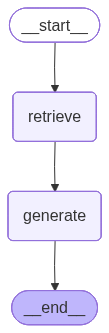

In [21]:
graph

In [22]:
test_query = "How will EVS impact oil demand in the next decade?"

result = graph.invoke({"query": test_query, "messages": []})

In [23]:
print("=== GENERATED RESPONSE ===")
print(result["generation"])

=== GENERATED RESPONSE ===
Short answer
- EVs will reduce oil demand by a meaningful but not yet overwhelming amount over the next decade. Projections put EVs at 40–60% of new car sales by 2030 and the global EV fleet rising from ~40 million today to roughly 300–500 million by the early 2030s, but full fleet turnover takes much longer.

Key numbers from the report
- Global passenger vehicle stock ≈ 1.4 billion; annual new vehicle sales ≈ 90 million; average vehicle lifetime 15–20 years (longer in some markets) — so fleet electrification is multi‑decade.
- Under OPEC’s central scenario, EVs displace only about 2–3 million barrels per day (mb/d) of oil by 2030.
- The IEA vs OPEC projection gap implies uncertainty of roughly 5–7 mb/d of displacement by 2030 across plausible scenarios.

Why the impact is uncertain
- Projecting displacement requires combining: new EV sales, ICE retirement rates, and the mileage/fuel-economy of displaced vehicles.
- Heavy trucking, aviation, shipping and pet

In [24]:
print("\n=== RETRIEVED DOCUMENTS ===")
for i, doc in enumerate(result["retrieved_docs"], 1):
    source = doc.metadata.get("source", "unknown")
    page = doc.metadata.get("page", "?")
    snippet = doc.page_content[:500].replace("\n", " ")
    print(f"[{i}] Source: {source} | Page: {page}")
    print(f"    {snippet}...")


=== RETRIEVED DOCUMENTS ===
[1] Source: ./Documents/evs_oil_price_shock.pdf | Page: 3
    Energy Agency, and McKinsey collectively project that EVs will account for between 40 and 60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which matters more than annual sales for oil displacement — is projected to grow from roughly 40 million vehicles today to between 300 and 500 million by the early 2030s. Whether this is sufficient to materially alter the oil price formation process is the central question this report addresses. 1.1 Scope and Methodology  This ...
[2] Source: ./Documents/evs_oil_price_shock.pdf | Page: 7
    Will EVs Dampen the Oil Price Shock? Version 1.0 Research Report — For Educational and RAG Pipeline Use Page 8 4. EV Adoption Trajectories and Oil Demand Displacement  Projecting oil demand displacement from EV adoption requires integrating three distinct analytical layers: the annual sales trajectory for new EVs, the retirement rate of the 

In [25]:
print(result["context"])

Energy Agency, and McKinsey collectively project that EVs will account for between 40 and
60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which
matters more than annual sales for oil displacement — is projected to grow from roughly 40
million vehicles today to between 300 and 500 million by the early 2030s. Whether this is
sufficient to materially alter the oil price formation process is the central question this report
addresses.
1.1 Scope and Methodology
 This report focuses on the relationship between passenger and light commercial vehicle
electrification and global oil demand dynamics. Heavy trucking, aviation, shipping, and
petrochemical feedstock demand — which collectively account for roughly 43 percent of oil
consumption — are not the primary subject of analysis, though their trajectories are

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 8
4. EV Adoption Trajectories and Oil Demand 